## Sentiment Analysis

### Load Data

In [4]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

# Read raw data
master_dir = os.path.dirname(os.getcwd())

processed_reviews = os.path.join(master_dir, "data", "processed_data", "feature_engineered_reviews.csv")

df_processed = pd.read_csv(processed_reviews)

df_processed.head()

,Review_ID,Review,Rating,Lemmatized_Tokens,Review_lemmatized,Platform,Restaurant,Sentiment_Label
0,R000001,came here for the high tea. great service espe...,4.0,"['come', 'high', 'tea', '.', 'great', 'service...",come high tea . great service especially mr. j...,Google,Cuisines Restaurant,positive
1,R000002,"5 stars for the service, even though some of t...",2.0,"['5', 'star', 'service', ',', 'even', 'though'...","5 star service , even though staff need train ...",Google,Cuisines Restaurant,negative
2,R000003,"hi, thank you for your service. but! i feel so...",1.0,"['hi', ',', 'thank', 'service', '.', 'but', '!...","hi , thank service . but ! feel so sorry food ...",Google,Cuisines Restaurant,negative
3,R000004,i have the worse buffer dinner ever so far. th...,1.0,"['bad', 'buffer', 'dinner', 'ever', 'so', 'far...",bad buffer dinner ever so far . spread so smal...,Google,Cuisines Restaurant,negative
4,R000005,"that is are known 5 elmark "" 9h72 "" & kdk "" 3 ...",5.0,"['know', '5', 'elmark', '``', '9h72', '``', '&...",know 5 elmark `` 9h72 `` & kdk `` 3 k14y9 & 1 ...,Google,Cuisines Restaurant,positive


### BERT

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader
from tqdm import tqdm

# 1. Setup GPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # Must print 'cuda', NOT 'cpu'

Using device: cuda


In [3]:
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

CUDA available: True
Device count: 1


In [5]:
# 2. Load Model & Tokenizer with FP16 Precision
MODEL_NAME = "terrencewee12/xlm-roberta-base-sentiment-multilingual-finetuned-v3"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    torch_dtype=torch.float16
).to(device)
model.eval()

Invalid model-index. Not loading eval results into CardData.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=3, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Li

In [ ]:
# 3. Using the cleaned but not yet tokenized reviews, we will convert them to a list of strings for batch processing
reviews = df_processed["Review"].astype(str).tolist()

In [22]:
# 4. Batch prediction function returning both Labels and Scores
def predict_sentiment(text_list, batch_size=64, max_len=256):
    labels = []
    scores = []
    
    # ID to string mapping from model configuration
    id2label = model.config.id2label
    
    with torch.no_grad():
        for i in tqdm(range(0, len(text_list), batch_size), desc="Inferring"):
            batch_texts = text_list[i : i + batch_size]
            
            inputs = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_len,
                return_tensors="pt"
            ).to(device)

            outputs = model(**inputs)
            
            # Apply softmax to get probability scores (0.0 to 1.0)
            probabilities = torch.softmax(outputs.logits, dim=-1)
            
            # Extract max probability and corresponding class ID
            max_scores, class_ids = torch.max(probabilities, dim=-1)
            
            # Map predictions to label strings and float scores
            for cid, score in zip(class_ids.cpu().tolist(), max_scores.cpu().tolist()):
                labels.append(id2label[cid].capitalize())
                scores.append(round(score, 4))
                
    return labels, scores
          

In [23]:
# Execute inference
bert_labels, bert_scores = predict_sentiment(reviews, batch_size=64, max_len=256)

Inferring: 100%|██████████| 5653/5653 [31:28<00:00,  2.99it/s]


In [24]:
# 5. Assign results to DataFrame
df_processed["BERT_Sentiment"] = bert_labels
df_processed["BERT_Score"] = bert_scores

In [25]:
df_processed[["Review","Rating","BERT_Sentiment","BERT_Score"]].head(10)

,Review,Rating,BERT_Sentiment,BERT_Score
0,came here for the high tea. great service espe...,4.0,Positive,0.7637
1,"5 stars for the service, even though some of t...",2.0,Positive,0.5098
2,"hi, thank you for your service. but! i feel so...",1.0,Negative,0.7056
3,i have the worse buffer dinner ever so far. th...,1.0,Negative,0.9365
4,"that is are known 5 elmark "" 9h72 "" & kdk "" 3 ...",5.0,Negative,0.4753
5,i just came back from there. 2 adults and 4 yo...,2.0,Negative,0.8867
6,restaurant looks nice but taste is bad. i had ...,2.0,Negative,0.7720
7,"pros: ambience is great with lake view, good a...",4.0,Negative,0.4070
8,we went to this place after reviews on tripadv...,1.0,Negative,0.9229
9,"the restaurant is located inside the hotel, th...",4.0,Positive,0.7314


In [ ]:
# Get the counts of each sentiment label
sentiment_counts = df_processed["BERT_Sentiment"].value_counts()

print(sentiment_counts)

BERT_Sentiment
Positive    262253
Negative     81567
Neutral      17942
Name: count, dtype: int64


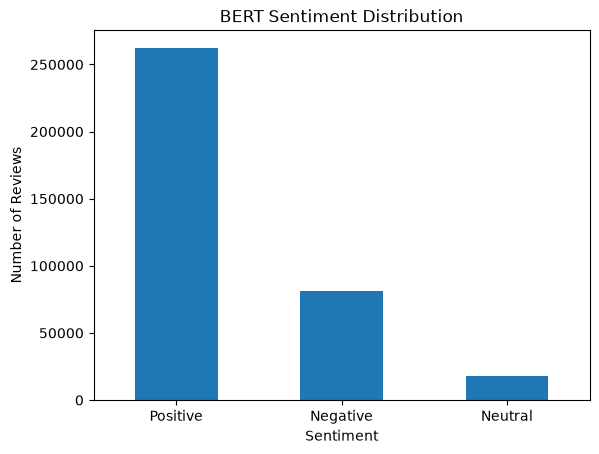

In [27]:
import matplotlib.pyplot as plt

df_processed["BERT_Sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("BERT Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [29]:
pd.crosstab(
    df_processed["Sentiment_Label"],
    df_processed["BERT_Sentiment"],
    margins=True
)

BERT_Sentiment,Negative,Neutral,Positive,All
Sentiment_Label,,,,
negative,28900,1100,2200,32200
neutral,21352,2975,15504,39831
positive,31315,13867,244549,289731
All,81567,17942,262253,361762


In [ ]:
# Calc the agreement between the original sentiment labels and BERT predictions
agreement = (
    df_processed["Sentiment_Label"].str.lower() ==
    df_processed["BERT_Sentiment"].str.lower()
)

print(
    "Agreement:",
    agreement.mean() * 100,
    "%"
)

Agreement: 76.41045770423649 %


In [ ]:
# Extract the disagreements reviews between the original sentiment labels and BERT predictions
disagreements = df_processed[
    df_processed["Sentiment_Label"].str.lower() != df_processed["BERT_Sentiment"].str.lower()
].copy()

print("Number of disagreements:", len(disagreements))

Number of disagreements: 85338


In [ ]:
# Display the disagreements reviews
with pd.option_context('display.max_colwidth', None):
    display(disagreements[
        [
            "Review",
            "Rating",
            "Sentiment_Label",
            "BERT_Sentiment",
            "BERT_Score"
        ]
    ].head(10))

,Review,Rating,Sentiment_Label,BERT_Sentiment,BERT_Score
1,"5 stars for the service, even though some of the staffs need to be trained better, but that does not affect the overall experience. i am from the industry itself so they should be given the opportunities. …more5 stars for the service, even though some of the staffs need to be trained better, but that does not affect the overall experience. i am from the industry itself so they should be given the opportunities.as for the food, seriously need improvement, it is not value for money at all. really disappointed on the food since it is attached to a 5 star resort so had high expectation.",2.0,negative,Positive,0.5098
4,"that is are known 5 elmark "" 9h72 "" & kdk "" 3 k14y9 & 1 k14y5 "" ceiling fan cannot believe was known nice restaurant is not that upcoming video kipas siling",5.0,positive,Negative,0.4753
7,"pros: ambience is great with lake view, good air condition restaurant due ipoh weather always hot, good and fast service waiter and waitress, accept touch and go e-wallet, free parking but open under hot sunshine, food tastes good …morepros: ambience is great with lake view, good air condition restaurant due ipoh weather always hot, good and fast service waiter and waitress, accept touch and go e-wallet, free parking but open under hot sunshine, food tastes good especially fried kuey tiaw, great service from security guard guided escorted me from guard house until restaurant.cons: car park under hot sunshine and very limited covered car park.overall service is okay, cheaper than the banjaran which neighbor to this the haven, but service quality and offered use totally different.",4.0,positive,Negative,0.4070
10,overall just okay. can further improve.,3.0,neutral,Positive,0.9580
11,no 1 in ipoh. worth the try.,5.0,positive,Neutral,0.3831
14,the ala carte food in the menu is quite expensive but luckily the environment there are quite superb and nice,3.0,neutral,Positive,0.9468
20,"went here for the smoke duck. was told its pork, lard free. they serve alcohol drinks here. …morewent here for the smoke duck. was told its pork, lard free. they serve alcohol drinks here.read from reviews, got 1 customer said he willing to come here from usa for the smoke duck apart from the one in hong kong. so we thought to give it a try while staying at weil hotel.luckily we came early as we just realized they open at 6pm till 8pm! and luckily it was not full house. was told by the staffs, usually their duck sold out. we are lucky enough to get to try! saw another guests already booked their table. staffs are very attentive even recommended us good foods apart from the duck.and of course the smoked ducks taste absolutely amazing. the skin so crispy and the spices not overpowering. very tender & no fishy taste from the duck. we forgot what the other dish called but it was terrific as well. probably will be in our list to eat in ipoh next time. price is very affordable for us. half duck costed rm 45! that is almost the same as kl price in a normal restaurant but the quality is like from a five star hotel restaurant!overall a very satisfying experience. too bad they no longer serve dim sum. i would say this place kind of underdog as they do not have much reviews on google but plenty reviews on trip advisor. so it was a tough pick initially for us google generation.if you are looking for a convenient 5 star setting of a chinese restaurant with amazing smoked duck - this is a must to go place. you will not regret it as our tongues did rolling_on_the_floor_laughing",5.0,positive,Negative,0.5591
21,"yuk sou hin has got the best dim sum in ipoh in my opinion. there are only 2 possible outcomes when you eat their dim sums: a moment of silence as you ruminate over those soothingly delicate morsels or a gasp of amazement by the unexpected …moreyuk sou hin has got the best dim sum in ipoh in my opinion. there are only 2 possible outcomes when you eat their dim sums: a moment of silence as you ruminat

In [ ]:
# Extract low-confidence predictions (BERT_Score < 0.60)
low_confidence = df_processed[
    df_processed["BERT_Score"] < 0.60
].copy()

print("Low-confidence predictions:", len(low_confidence))

Low-confidence predictions: 90292


In [ ]:
# see what review make teh BERT model have low confidence
low_confidence[
    [
        "Review",
        "Rating",
        "BERT_Sentiment",
        "BERT_Score"
    ]
].head(20)

with pd.option_context('display.max_colwidth', None):
    display(low_confidence[
        [
            "Review",
            "Rating",
            "BERT_Sentiment",
            "BERT_Score"
        ]
    ].head(10))

,Review,Rating,BERT_Sentiment,BERT_Score
1,"5 stars for the service, even though some of the staffs need to be trained better, but that does not affect the overall experience. i am from the industry itself so they should be given the opportunities. …more5 stars for the service, even though some of the staffs need to be trained better, but that does not affect the overall experience. i am from the industry itself so they should be given the opportunities.as for the food, seriously need improvement, it is not value for money at all. really disappointed on the food since it is attached to a 5 star resort so had high expectation.",2.0,Positive,0.5098
4,"that is are known 5 elmark "" 9h72 "" & kdk "" 3 k14y9 & 1 k14y5 "" ceiling fan cannot believe was known nice restaurant is not that upcoming video kipas siling",5.0,Negative,0.4753
7,"pros: ambience is great with lake view, good air condition restaurant due ipoh weather always hot, good and fast service waiter and waitress, accept touch and go e-wallet, free parking but open under hot sunshine, food tastes good …morepros: ambience is great with lake view, good air condition restaurant due ipoh weather always hot, good and fast service waiter and waitress, accept touch and go e-wallet, free parking but open under hot sunshine, food tastes good especially fried kuey tiaw, great service from security guard guided escorted me from guard house until restaurant.cons: car park under hot sunshine and very limited covered car park.overall service is okay, cheaper than the banjaran which neighbor to this the haven, but service quality and offered use totally different.",4.0,Negative,0.4070
11,no 1 in ipoh. worth the try.,5.0,Neutral,0.3831
19,food is delicious face_savoring_food 5 star service thumbs_up_light_skin_tone the environment is very beautiful thumbs_up_light_skin_tone …more food is delicious face_savoring_food 5 star service thumbs_up_light_skin_tone the environment is very beautiful thumbs_up_light_skin_tone (original)食物好吃 face_savoring_food 5星级服务 thumbs_up_light_skin_tone 环境非常优美 thumbs_up_light_skin_tone,5.0,Positive,0.3633
20,"went here for the smoke duck. was told its pork, lard free. they serve alcohol drinks here. …morewent here for the smoke duck. was told its pork, lard free. they serve alcohol drinks here.read from reviews, got 1 customer said he willing to come here from usa for the smoke duck apart from the one in hong kong. so we thought to give it a try while staying at weil hotel.luckily we came early as we just realized they open at 6pm till 8pm! and luckily it was not full house. was told by the staffs, usually their duck sold out. we are lucky enough to get to try! saw another guests already booked their table. staffs are very attentive even recommended us good foods apart from the duck.and of course the smoked ducks taste absolutely amazing. the skin so crispy and the spices not overpowering. very tender & no fishy taste from the duck. we forgot what the other dish called but it was terrific as well. probably will be in our list to eat in ipoh next time. price is very affordable for us. half duck costed rm 45! that is almost the same as kl price in a normal restaurant but the quality is like from a five star hotel restaurant!overall a very satisfying experience. too bad they no longer serve dim sum. i would say this place kind of underdog as they do not have much reviews on google but plenty reviews on trip advisor. so it was a tough pick initially for us google generation.if you are looking for a convenient 5 star setting of a chinese restaurant with amazing smoked duck - this is a must to go place. you will not regret it as our tongues did rolling_on_the_floor_laughing",5.0,Negative,0.5591
21,"yuk sou hin has got the best dim sum in ipoh in my opinion. there are only 2 possible outcomes when you eat their dim sums: a moment of silence as you ruminate over those soothingly delicate morsels or a gasp of amazement by the unexpected …moreyuk sou hin has got the bes

In [44]:
def confidence_category(score):
    if score >= 0.80:
        return "High"
    elif score >= 0.60:
        return "Medium"
    else:
        return "Low"

df_processed["BERT_Confidence"] = df_processed["BERT_Score"].apply(
    confidence_category
)

In [46]:
df_processed["BERT_Confidence"].value_counts()

BERT_Confidence
High      198015
Low        90292
Medium     73455
Name: count, dtype: int64